# Visualization with Matplotlib

Numbers become insight when you can see them. Matplotlib is Python's foundational plotting library; everything from a quick line chart to publication-quality figures with custom annotations. It integrates directly with NumPy arrays and pandas DataFrames, making it a natural next step after those notebooks.

**What's inside:** line, scatter, bar, and histogram plots; subplots and figure layout; styling with colors, markers, and linestyles; labels, titles, and legends; annotations; saving figures; and plotting directly from NumPy and pandas.

**Learn more:** [Matplotlib](https://matplotlib.org/stable/index.html) · [pyplot tutorial](https://matplotlib.org/stable/tutorials/pyplot.html)

## Setup

In [ ]:
%pip install matplotlib numpy pandas

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# render plots inline in the notebook
%matplotlib inline
plt.rcParams['figure.dpi'] = 100    # sharper output

## 1. Basic Plot Types

### 1.1 Line plot

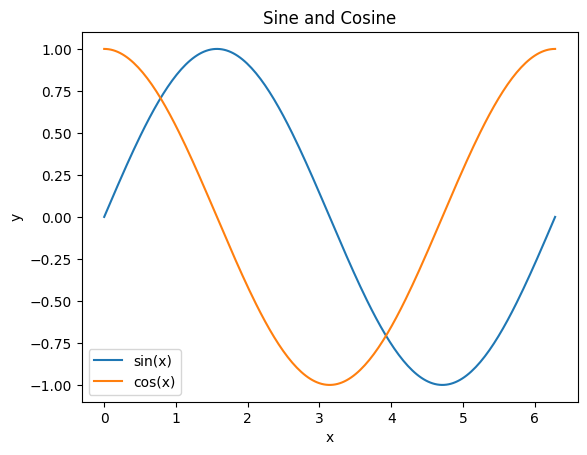

In [2]:
x = np.linspace(0, 2 * np.pi, 200)

fig, ax = plt.subplots()
ax.plot(x, np.sin(x), label='sin(x)')
ax.plot(x, np.cos(x), label='cos(x)')
ax.set_title('Sine and Cosine')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
plt.show()

### 1.2 Scatter plot

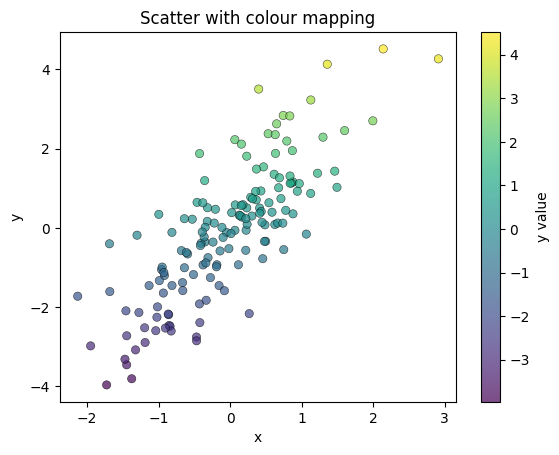

In [3]:
rng = np.random.default_rng(42)
n = 150
x = rng.normal(0, 1, n)
y = x * 1.5 + rng.normal(0, 1, n)

fig, ax = plt.subplots()
scatter = ax.scatter(x, y, c=y, cmap='viridis', alpha=0.7, edgecolors='k', linewidths=0.4)
fig.colorbar(scatter, ax=ax, label='y value')
ax.set_title('Scatter with colour mapping')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()

### 1.3 Bar chart

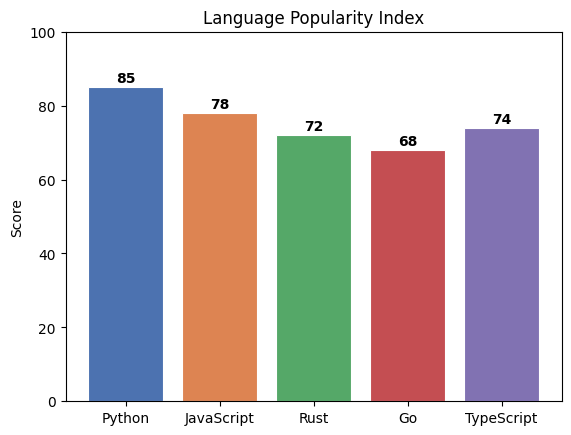

In [4]:
languages = ['Python', 'JavaScript', 'Rust', 'Go', 'TypeScript']
scores    = [85, 78, 72, 68, 74]
colors    = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots()
bars = ax.bar(languages, scores, color=colors, edgecolor='white', linewidth=0.8)

# add value labels on top of each bar
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(score), ha='center', va='bottom', fontweight='bold')

ax.set_title('Language Popularity Index')
ax.set_ylabel('Score')
ax.set_ylim(0, 100)
plt.show()

### 1.4 Histogram

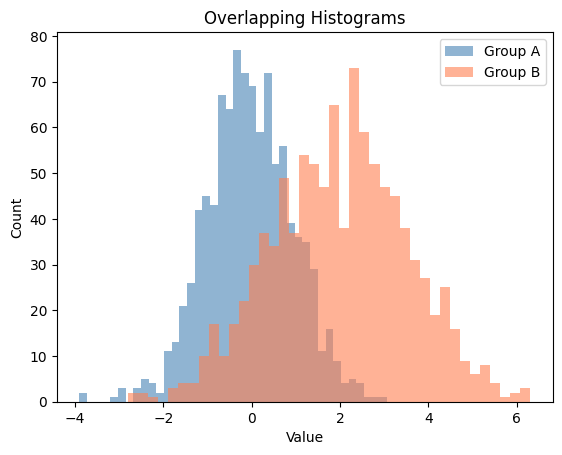

In [5]:
rng = np.random.default_rng(0)
data_a = rng.normal(loc=0, scale=1, size=1000)
data_b = rng.normal(loc=2, scale=1.5, size=1000)

fig, ax = plt.subplots()
ax.hist(data_a, bins=40, alpha=0.6, label='Group A', color='steelblue')
ax.hist(data_b, bins=40, alpha=0.6, label='Group B', color='coral')
ax.set_title('Overlapping Histograms')
ax.set_xlabel('Value')
ax.set_ylabel('Count')
ax.legend()
plt.show()

## 2. Subplots: Multiple Panels

`plt.subplots(rows, cols)` returns a figure and an array of axes objects.

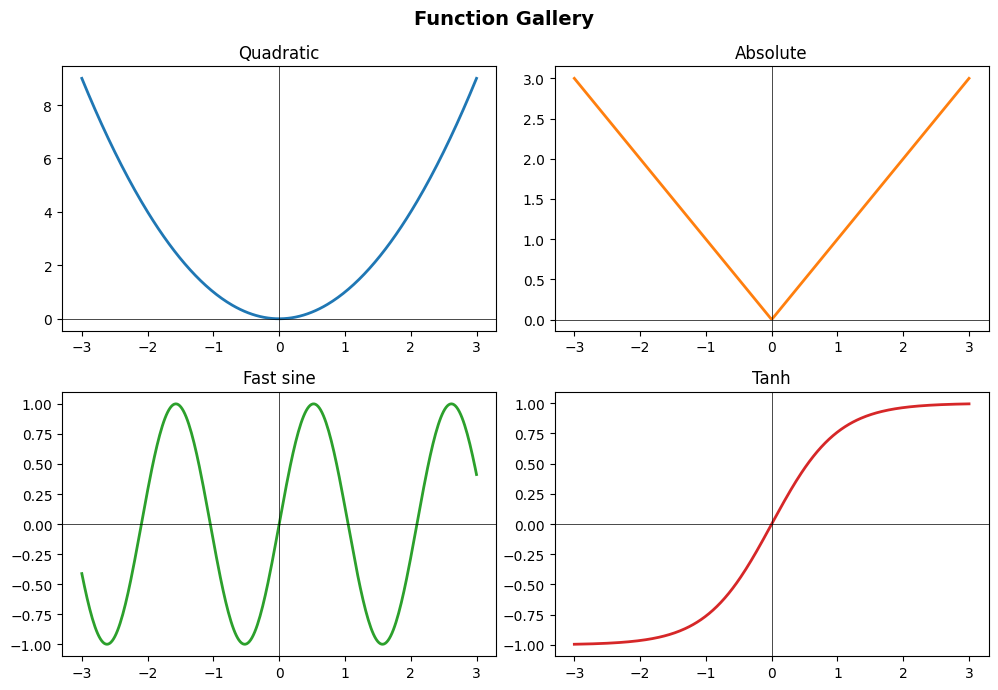

In [6]:
x = np.linspace(-3, 3, 300)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle('Function Gallery', fontsize=14, fontweight='bold')

plots = [
    (x, x**2,           'Quadratic',    'tab:blue'),
    (x, np.abs(x),      'Absolute',     'tab:orange'),
    (x, np.sin(x * 3),  'Fast sine',    'tab:green'),
    (x, np.tanh(x),     'Tanh',         'tab:red'),
]

for ax, (xd, yd, title, color) in zip(axes.flat, plots):
    ax.plot(xd, yd, color=color, linewidth=2)
    ax.set_title(title)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

## 3. Styling: Colors, Markers, Linestyles

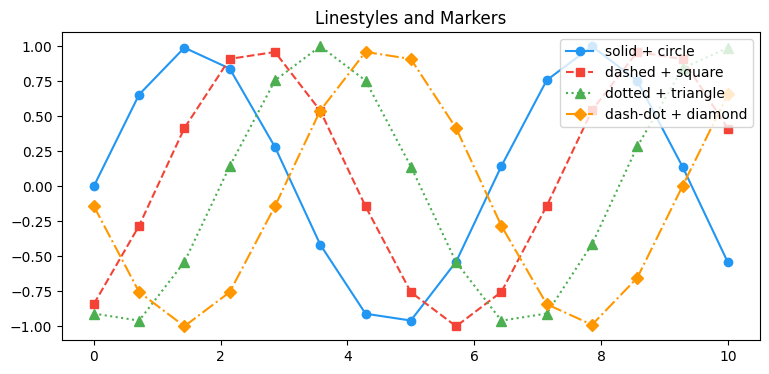

In [7]:
x = np.linspace(0, 10, 15)

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(x, np.sin(x),              color='#2196F3', linestyle='-',  marker='o', markersize=6, label='solid + circle')
ax.plot(x, np.sin(x - 1),         color='#F44336', linestyle='--', marker='s', markersize=6, label='dashed + square')
ax.plot(x, np.sin(x - 2),         color='#4CAF50', linestyle=':',  marker='^', markersize=7, label='dotted + triangle')
ax.plot(x, np.sin(x - 3),         color='#FF9800', linestyle='-.', marker='D', markersize=6, label='dash-dot + diamond')

ax.set_title('Linestyles and Markers')
ax.legend(loc='upper right')
plt.show()

## 4. Annotations

`ax.annotate` draws an arrow from text to a point, useful for calling out extrema, events, or thresholds.

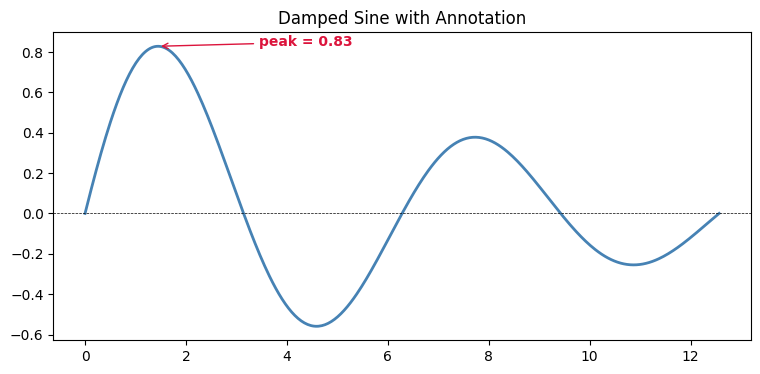

In [8]:
x = np.linspace(0, 4 * np.pi, 400)
y = np.sin(x) * np.exp(-x / 8)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, y, color='steelblue', linewidth=2)

# find and annotate the global maximum
peak_idx = np.argmax(y)
ax.annotate(
    f'peak = {y[peak_idx]:.2f}',
    xy=(x[peak_idx], y[peak_idx]),           # point to annotate
    xytext=(x[peak_idx] + 2, y[peak_idx]),   # text position
    arrowprops=dict(arrowstyle='->', color='crimson'),
    color='crimson', fontweight='bold'
)

ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('Damped Sine with Annotation')
plt.show()

## 5. Plotting from pandas and NumPy

DataFrames and arrays plug in directly, with no explicit x/y extraction needed.

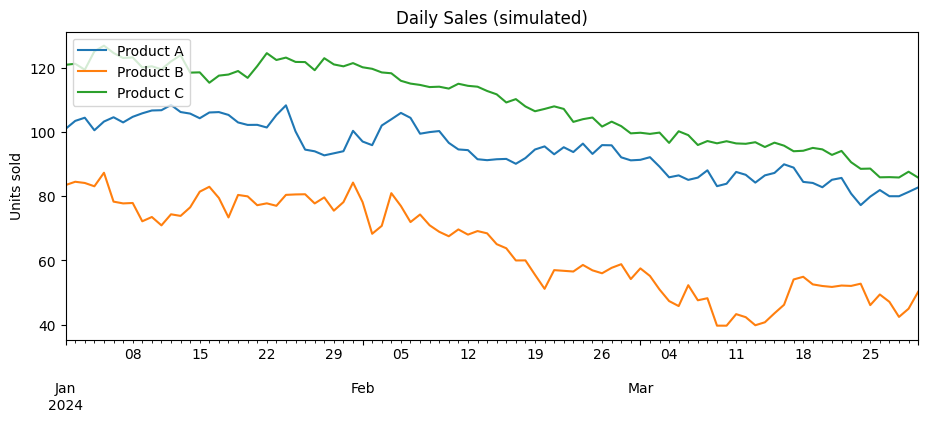

In [9]:
import pandas as pd
import numpy as np

# build a synthetic time-series DataFrame
rng = np.random.default_rng(1)
dates = pd.date_range('2024-01-01', periods=90, freq='D')
df = pd.DataFrame({
    'Product A': 100 + np.cumsum(rng.normal(0, 3, 90)),
    'Product B':  80 + np.cumsum(rng.normal(0, 4, 90)),
    'Product C': 120 + np.cumsum(rng.normal(0, 2, 90)),
}, index=dates)

fig, ax = plt.subplots(figsize=(11, 4))
df.plot(ax=ax)                  # pandas calls Matplotlib under the hood
ax.set_title('Daily Sales (simulated)')
ax.set_ylabel('Units sold')
ax.legend(loc='upper left')
plt.show()

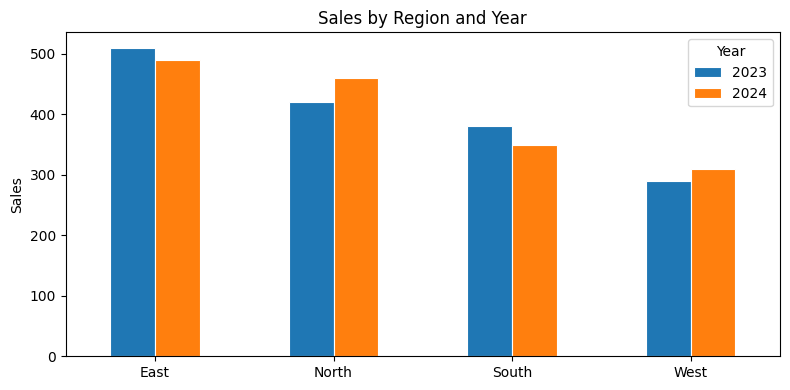

In [10]:
# bar chart from a pandas groupby result
data = pd.DataFrame({
    'region': ['North', 'South', 'East', 'West', 'North', 'South', 'East', 'West'],
    'sales':  [420, 380, 510, 290, 460, 350, 490, 310],
    'year':   [2023, 2023, 2023, 2023, 2024, 2024, 2024, 2024],
})

pivot = data.pivot_table(index='region', columns='year', values='sales', aggfunc='sum')

fig, ax = plt.subplots(figsize=(8, 4))
pivot.plot(kind='bar', ax=ax, edgecolor='white', linewidth=0.8)
ax.set_title('Sales by Region and Year')
ax.set_ylabel('Sales')
ax.set_xlabel('')
ax.legend(title='Year')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Saving Figures

saved to C:\Users\saxma\AppData\Local\Temp\plot.png
file size: 32,331 bytes


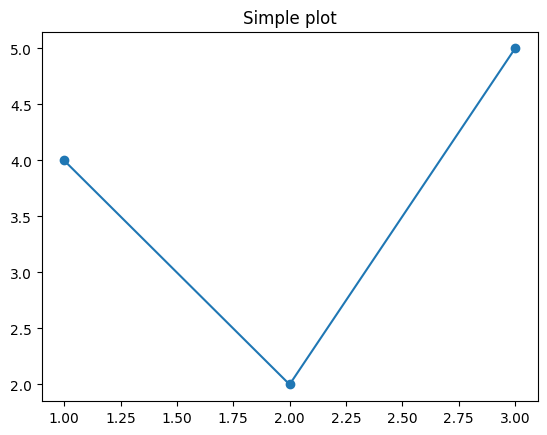

In [11]:
import tempfile, os

fig, ax = plt.subplots()
ax.plot([1, 2, 3], [4, 2, 5], marker='o')
ax.set_title('Simple plot')

# savefig (format is inferred from extension)
path = os.path.join(tempfile.gettempdir(), 'plot.png')
fig.savefig(path, dpi=150, bbox_inches='tight')   # tight removes excess whitespace

print(f'saved to {path}')
print(f'file size: {os.path.getsize(path):,} bytes')